In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly .express as px

In [2]:
df = pd.read_csv("indian_tech_jobs_2026.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23201 entries, 0 to 23200
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   job_id               23201 non-null  int64  
 1   job_title            23201 non-null  str    
 2   company_name         23201 non-null  str    
 3   company_rating       23201 non-null  float64
 4   location             23201 non-null  str    
 5   scraped_city         23201 non-null  str    
 6   role_category        23201 non-null  str    
 7   experience_raw       23201 non-null  str    
 8   experience_min_yrs   23201 non-null  int64  
 9   experience_max_yrs   23201 non-null  int64  
 10  salary_raw           23201 non-null  str    
 11  salary_min_lpa       23201 non-null  float64
 12  salary_max_lpa       23201 non-null  float64
 13  salary_disclosed     23201 non-null  bool   
 14  skills_required      23201 non-null  str    
 15  skills_count         23201 non-null  int64  
 1

In [4]:
df.tail(10)

,job_id,job_title,company_name,company_rating,location,scraped_city,role_category,experience_raw,experience_min_yrs,experience_max_yrs,...,scraped_at,salary_tier,experience_tier,is_senior,primary_city,skill_domain,salary_midpoint_lpa,days_since_posted,is_fresher_friendly,salary_negotiable
23191,23192,Python Developer,Persistent,3.6,Hyderabad,Hyderabad,Python Developer,3-7 Yrs,3,7,...,10-06-2025,Undisclosed,Mid (3-5 Yrs),False,Hyderabad,Data Science,0.0,14,False,False
23192,23193,Python Developer - Third Party payroll,Crisil,3.6,Hyderabad,Hyderabad,Python Developer,2-5 Yrs,2,5,...,10-06-2025,Undisclosed,Junior (0-2 Yrs),False,Hyderabad,Data Engineering,0.0,21,False,False
23193,23194,Python Developer,Ltimindtree,3.6,"Hybrid - Hyderabad, Pune, Chennai",Hyderabad,Python Developer,4-8 Yrs,4,8,...,10-06-2025,Undisclosed,Mid (3-5 Yrs),False,Hyderabad,Data Science,0.0,14,False,False
23194,23195,Python Developer (GenAI),Scry Analytics,4.1,Hyderabad,Hyderabad,Python Developer,3-6 Yrs,3,6,...,10-06-2025,Undisclosed,Mid (3-5 Yrs),False,Hyderabad,AI/ML/DL,0.0,21,False,False
23195,23196,Python Developer,Movate Technologies,3.1,Hyderabad,Hyderabad,Python Developer,5-8 Yrs,5,8,...,10-06-2025,Undisclosed,Mid (3-5 Yrs),False,Hyderabad,Cloud & DevOps,0.0,21,False,False
23196,23197,Python Developer-Hyderabad,Infosys,3.5,Hybrid - Hyderabad,Hyderabad,Python Developer,2-7 Yrs,2,7,...,10-06-2025,Undisclosed,Junior (0-2 Yrs),False,Hyderabad,Data Science,0.0,1,False,False
23197,23198,Python Developer,Accufy,3.6,Hyderabad,Hyderabad,Python Developer,0-4 Yrs,0,4,...,10-06-2025,Undisclosed,Fresher,False,Hyderabad,Data Science,0.0,1,True,False
23198,23199,Walk in Interview Python Developer II Hyderabad,Tata Consultancy Services,3.3,"Hyderabad, Pune, Mumbai (All Areas)",Hyderabad,Python Developer,13-Jun,13,8,...,10-06-2025,Undisclosed,Lead/Architect (9+ Yrs),False,Hyderabad,Data Engineering,0.0,21,False,False
23199,23200,Python Developer,Mediamint,2.8,Hybrid - Hyderabad,Hyderabad,Python Developer,3-5 Yrs,3,5,...,10-06-2025,Undisclosed,Mid (3-5 Yrs),False,Hyderabad,Data Science,0.0,0,False,False
23200,23201,Python Developer,CMM Level 5 IT Company,3.6,Hyderabad,Hyderabad,Python Developer,7-12 Yrs,7,12,...,10-06-2025,Senior (10-20 LPA),Senior (6-8 Yrs),False,Hyderabad,Data Science,13.0,1,False,False


In [5]:
df.head(10)

,job_id,job_title,company_name,company_rating,location,scraped_city,role_category,experience_raw,experience_min_yrs,experience_max_yrs,...,scraped_at,salary_tier,experience_tier,is_senior,primary_city,skill_domain,salary_midpoint_lpa,days_since_posted,is_fresher_friendly,salary_negotiable
0,1,Data Scientist,Cisco,4.1,Bengaluru,Bangalore,Data Scientist,7-10 Yrs,7,10,...,10-06-2025,Undisclosed,Senior (6-8 Yrs),False,Bangalore,Business Intelligence,0.0,21,False,False
1,2,Data Scientist,Caterpillar Inc,4.1,Bengaluru,Bangalore,Data Scientist,4-8 Yrs,4,8,...,10-06-2025,Undisclosed,Mid (3-5 Yrs),False,Bangalore,AI/ML/DL,0.0,21,False,False
2,3,Analytics Data Scientist,Foreign IT Consulting MNC,3.6,"Hyderabad, Chennai, Bengaluru",Bangalore,Data Scientist,4-9 Yrs,4,9,...,10-06-2025,Undisclosed,Mid (3-5 Yrs),False,Hyderabad,Business Intelligence,0.0,21,False,False
3,4,Data Scientist,Fortune 500 IT Services Company,3.6,"Mumbai, Bengaluru",Bangalore,Data Scientist,10-14 Yrs,0,0,...,10-06-2025,Undisclosed,Fresher,False,Mumbai,Data Science,0.0,21,True,False
4,5,Sr. Artificial Intelligence Engineer,Fortune 500 Product-based MNC,3.6,"Pune, Bengaluru",Bangalore,Data Scientist,5-10 Yrs,5,10,...,10-06-2025,Undisclosed,Mid (3-5 Yrs),True,Pune,Data Science,0.0,21,False,False
5,6,Data Scientist,Top Rated IT Enterprise,3.6,"Chennai, Bengaluru",Bangalore,Data Scientist,3-8 Yrs,3,8,...,10-06-2025,Undisclosed,Mid (3-5 Yrs),False,Chennai,Data Science,0.0,21,False,False
6,7,Data Scientist,Leading IT Firm,3.6,"Chennai, Bengaluru",Bangalore,Data Scientist,5-10 Yrs,5,10,...,10-06-2025,Undisclosed,Mid (3-5 Yrs),False,Chennai,Data Science,0.0,21,False,False
7,8,Advanced Data Scientist,Exxon Mobil Corporation,3.7,Bengaluru,Bangalore,Data Scientist,5-10 Yrs,5,10,...,10-06-2025,Undisclosed,Mid (3-5 Yrs),False,Bangalore,AI/ML/DL,0.0,21,False,False
8,9,"Data Scientist, Google Play, Product",Google,4.4,Bengaluru,Bangalore,Data Scientist,5-10 Yrs,5,10,...,10-06-2025,Undisclosed,Mid (3-5 Yrs),False,Bangalore,AI/ML/DL,0.0,21,False,False
9,10,Machine Learning Data Scientist,Hsbc,3.8,Bengaluru,Bangalore,Data Scientist,3-7 Yrs,3,7,...,10-06-2025,Undisclosed,Mid (3-5 Yrs),False,Bangalore,AI/ML/DL,0.0,21,False,False


In [6]:
df.shape

(23201, 32)

In [7]:
df.isnull().sum()

job_id                  0
job_title               0
company_name            0
company_rating          0
location                0
scraped_city            0
role_category           0
experience_raw          0
experience_min_yrs      0
experience_max_yrs      0
salary_raw              0
salary_min_lpa          0
salary_max_lpa          0
salary_disclosed        0
skills_required         0
skills_count            0
job_description         0
posted_date_raw         0
work_mode               0
company_size_bucket     0
job_url                53
data_source             0
scraped_at              0
salary_tier             0
experience_tier         0
is_senior               0
primary_city            0
skill_domain            0
salary_midpoint_lpa     0
days_since_posted       0
is_fresher_friendly     0
salary_negotiable       0
dtype: int64

In [8]:
df = df.dropna(subset=['job_url'])

In [9]:
df.isnull().sum()

job_id                 0
job_title              0
company_name           0
company_rating         0
location               0
scraped_city           0
role_category          0
experience_raw         0
experience_min_yrs     0
experience_max_yrs     0
salary_raw             0
salary_min_lpa         0
salary_max_lpa         0
salary_disclosed       0
skills_required        0
skills_count           0
job_description        0
posted_date_raw        0
work_mode              0
company_size_bucket    0
job_url                0
data_source            0
scraped_at             0
salary_tier            0
experience_tier        0
is_senior              0
primary_city           0
skill_domain           0
salary_midpoint_lpa    0
days_since_posted      0
is_fresher_friendly    0
salary_negotiable      0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['work_mode'].unique()
df['role_category'].unique()
df['scraped_city'].unique()

<ArrowStringArray>
['Bangalore',    'Mumbai', 'Hyderabad',      'Pune',     'Delhi',   'Chennai',
     'Noida',   'Gurgaon',   'Kolkata', 'Ahmedabad',    'Remote']
Length: 11, dtype: str

In [12]:
df.describe()

,job_id,company_rating,experience_min_yrs,experience_max_yrs,salary_min_lpa,salary_max_lpa,skills_count,salary_midpoint_lpa,days_since_posted
count,23148.000000,23148.000000,23148.000000,23148.000000,23148.000000,23148.000000,23148.000000,23148.000000,23148.000000
mean,11612.378046,3.586444,4.134828,7.828625,1.386861,2.276646,7.620226,1.831754,15.689606
std,6695.671633,0.514830,2.934593,3.947594,4.846570,7.477058,1.415502,6.115654,7.579178
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5821.750000,3.400000,2.000000,5.000000,0.000000,0.000000,8.000000,0.000000,7.000000
50%,11610.500000,3.600000,4.000000,8.000000,0.000000,0.000000,8.000000,0.000000,21.000000
75%,17412.250000,3.800000,6.000000,10.000000,0.000000,0.000000,8.000000,0.000000,21.000000
max,23201.000000,5.000000,25.000000,31.000000,85.000000,90.000000,8.000000,87.500000,90.000000


In [13]:
df.to_csv('cleaned_indian_tech_jobs_2026.csv',index=False)

In [14]:
df.info()
df.head()

<class 'pandas.DataFrame'>
Index: 23148 entries, 0 to 23200
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   job_id               23148 non-null  int64  
 1   job_title            23148 non-null  str    
 2   company_name         23148 non-null  str    
 3   company_rating       23148 non-null  float64
 4   location             23148 non-null  str    
 5   scraped_city         23148 non-null  str    
 6   role_category        23148 non-null  str    
 7   experience_raw       23148 non-null  str    
 8   experience_min_yrs   23148 non-null  int64  
 9   experience_max_yrs   23148 non-null  int64  
 10  salary_raw           23148 non-null  str    
 11  salary_min_lpa       23148 non-null  float64
 12  salary_max_lpa       23148 non-null  float64
 13  salary_disclosed     23148 non-null  bool   
 14  skills_required      23148 non-null  str    
 15  skills_count         23148 non-null  int64  
 16  jo

,job_id,job_title,company_name,company_rating,location,scraped_city,role_category,experience_raw,experience_min_yrs,experience_max_yrs,...,scraped_at,salary_tier,experience_tier,is_senior,primary_city,skill_domain,salary_midpoint_lpa,days_since_posted,is_fresher_friendly,salary_negotiable
0,1,Data Scientist,Cisco,4.1,Bengaluru,Bangalore,Data Scientist,7-10 Yrs,7,10,...,10-06-2025,Undisclosed,Senior (6-8 Yrs),False,Bangalore,Business Intelligence,0.0,21,False,False
1,2,Data Scientist,Caterpillar Inc,4.1,Bengaluru,Bangalore,Data Scientist,4-8 Yrs,4,8,...,10-06-2025,Undisclosed,Mid (3-5 Yrs),False,Bangalore,AI/ML/DL,0.0,21,False,False
7,8,Advanced Data Scientist,Exxon Mobil Corporation,3.7,Bengaluru,Bangalore,Data Scientist,5-10 Yrs,5,10,...,10-06-2025,Undisclosed,Mid (3-5 Yrs),False,Bangalore,AI/ML/DL,0.0,21,False,False
8,9,"Data Scientist, Google Play, Product",Google,4.4,Bengaluru,Bangalore,Data Scientist,5-10 Yrs,5,10,...,10-06-2025,Undisclosed,Mid (3-5 Yrs),False,Bangalore,AI/ML/DL,0.0,21,False,False
9,10,Machine Learning Data Scientist,Hsbc,3.8,Bengaluru,Bangalore,Data Scientist,3-7 Yrs,3,7,...,10-06-2025,Undisclosed,Mid (3-5 Yrs),False,Bangalore,AI/ML/DL,0.0,21,False,False


In [15]:
df['role_category'].value_counts().head(10)

role_category
Data Scientist               6421
Data Analyst                 4729
Business Analyst             4503
Machine Learning Engineer    3987
Data Engineer                1922
Python Developer             1586
Name: count, dtype: int64

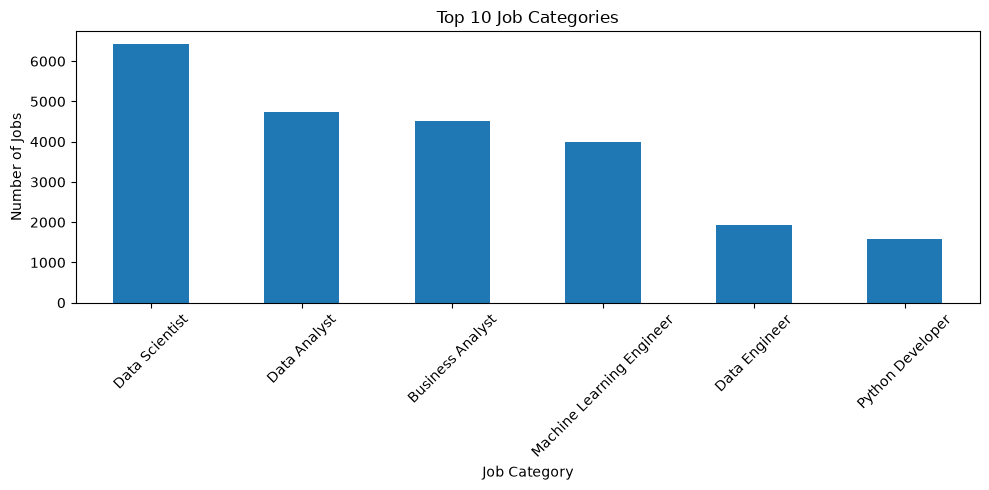

In [16]:
plt.figure(figsize=(10,5))
df['role_category'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Job Categories")
plt.xticks(rotation=45)
plt.xlabel("Job Category")
plt.ylabel("Number of Jobs")
plt.tight_layout()
plt.show()

In [17]:
df['primary_city'].value_counts().head(10)

primary_city
Mumbai       3267
Bangalore    2830
Chennai      2663
Pune         2604
Noida        2571
Gurgaon      2209
Remote       2010
Kolkata      1725
Ahmedabad    1352
Delhi         919
Name: count, dtype: int64

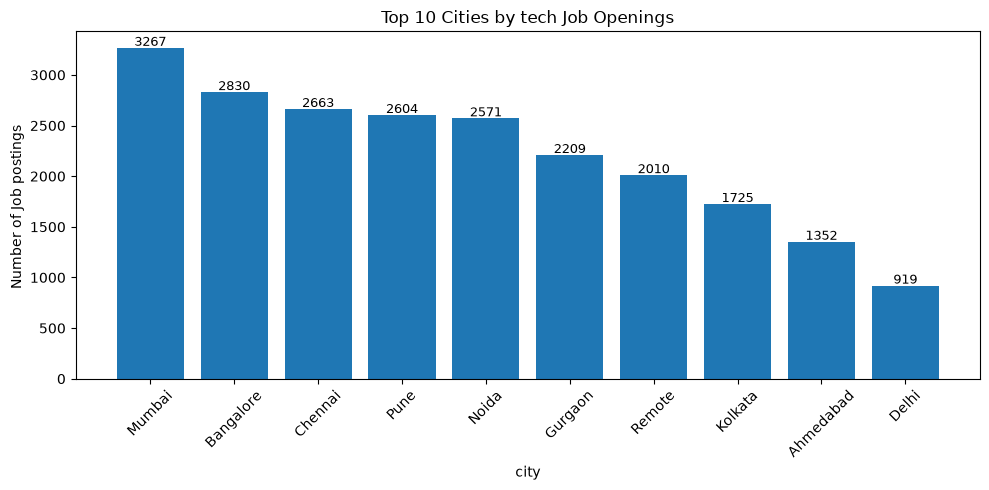

In [18]:
top_cities=df['primary_city'].value_counts().head(10)
plt.figure(figsize=(10,5))
bars = plt.bar(top_cities.index,top_cities.values)
plt.title("Top 10 Cities by tech Job Openings")
plt.xlabel("city")
plt.ylabel("Number of Job postings ")
plt.xticks(rotation=45)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 20,
        int(bar.get_height()),
        ha='center',
        fontsize=9
     )
plt.tight_layout()
plt.show()

In [19]:
df['company_name'].value_counts().head(10)

company_name
Tata Consultancy Services    653
Accenture                    438
EY                           340
Leading Client               243
Infosys                      209
Capgemini                    195
Photon                       193
Logic Planet                 185
Hexaware Technologies        147
Sparix Global                126
Name: count, dtype: int64

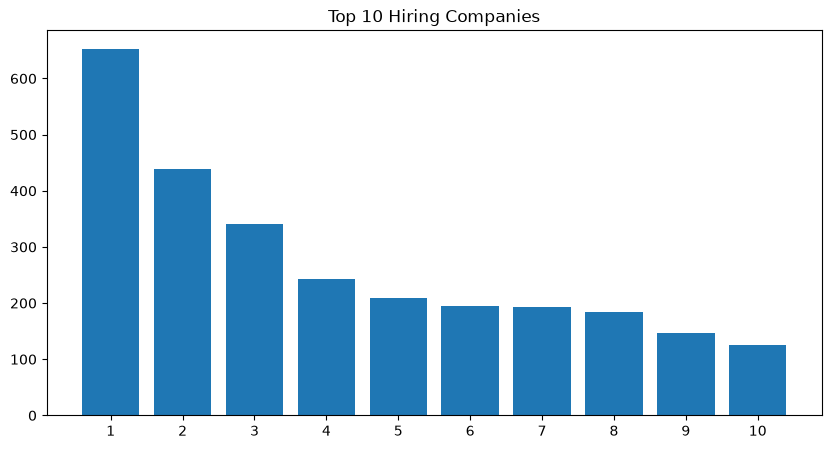

In [23]:
top_companies = df['company_name'].value_counts().head(10)
plt.figure(figsize=(10,5))
plt.bar(range(len(top_companies)),top_companies.values)

plt.xticks(range(len(top_companies)),range(1,11))
plt.title("Top 10 Hiring Companies")
plt.show()

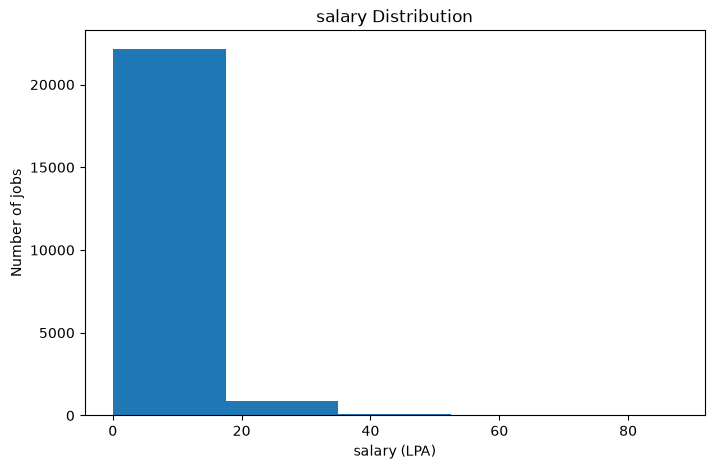

In [21]:
plt.figure(figsize=(8,5))
plt.hist(df['salary_midpoint_lpa'],bins=5)
plt.title("salary Distribution")
plt.xlabel("salary (LPA)")
plt.ylabel("Number of jobs")
plt.show()

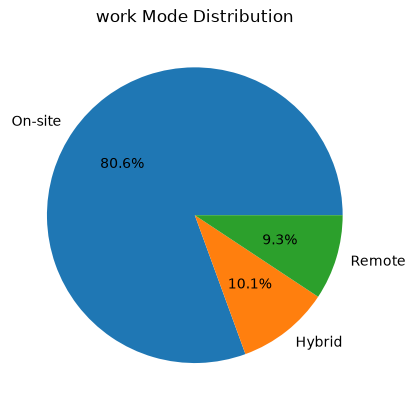

In [22]:
df['work_mode'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title("work Mode Distribution")
plt.ylabel("")
plt.show()